In [464]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.seasonal import MSTL, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import dtale
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import Normalizer, StandardScaler


sns.set_style('darkgrid')

In [465]:
def check_stationarity(series, name, sig=0.05):
    """
    ADF:  H_0 = niestacjonarny.  p < 0.05 -> stacjonarny
    KPSS: H_0 = stacjonarny.     p < 0.05 -> niestacjonarny
    """
    series = series.dropna()
    
    res_adf = adfuller(series, autolag='AIC')
    adf_stat, adf_p = round(res_adf[0], 3), round(res_adf[1], 3)
    adf_result = 'Stationary' if adf_p <= sig else 'Non-stationary'
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        res_kpss = kpss(series, regression='c', nlags='auto')
    kpss_stat, kpss_p = round(res_kpss[0], 3), round(res_kpss[1], 3)
    kpss_result = 'Non-stationary' if kpss_p <= sig else 'Stationary'
    
    if adf_result == 'Stationary' and kpss_result == 'Stationary':
        conclusion = 'Stationary'
    elif adf_result == 'Non-stationary' and kpss_result == 'Non-stationary':
        conclusion = 'Non-stationary (trend)'
    elif adf_result == 'Stationary' and kpss_result == 'Non-stationary':
        conclusion = 'Seasonal/trend-stationary'
    else:
        conclusion = 'Difference-stationary'
    
    return {
        'variable':    name,
        'ADF_stat':    adf_stat,
        'ADF_p':       adf_p,
        'ADF_result':  adf_result,
        'KPSS_stat':   kpss_stat,
        'KPSS_p':      kpss_p,
        'KPSS_result': kpss_result,
        'conclusion':  conclusion,
    }


In [466]:
# rows = [check_stationarity(df_mslt[f'{col}_resid'], name=col) for col in POLLUTANTS] # zle testy, jakies inne testy albo wystarczy diagnostyka residuów
# stationarity_table = pd.DataFrame(rows)

# stationarity_table

- Case 1: Both tests conclude that the series is not stationary - The series is not stationary
- Case 2: Both tests conclude that the series is stationary - The series is stationary
- Case 3: KPSS indicates stationarity and ADF indicates non-stationarity - The series is trend stationary. Trend needs to be removed to make series strict stationary. The detrended series is checked for stationarity.
- Case 4: KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity.
-biblioteka stats


In [467]:
df_gios = pd.read_csv("./data/cleaned_gios_daily.csv")
df_meteo = pd.read_csv("./data/cleaned_openmeteo_forecast_daily.csv")

In [469]:
df = pd.merge(df_gios, df_meteo, on='date', how='inner')
df = df.set_index('date')
df.index = pd.to_datetime(df.index)
date = df.index

In [362]:
df

,PM10,PM25,SO2,CO,NO2,O3,temperature_2m_mean,relative_humidity_2m_mean,pressure_msl_mean,precipitation_sum,snowfall_sum,shortwave_radiation_sum,cloudcover_mean,wind_u,wind_v
date,,,,,,,,,,,,,,,
2020-01-01,20.48,15.73,19.71,0.32,36.37,64.26,2.2,87,1032.9,0.0,0.00,2.75,36,-13.675158,4.180915
2020-01-02,77.82,68.60,15.17,1.17,62.94,34.55,-1.4,67,1028.8,0.0,0.00,4.44,9,-2.770363,-7.611510
2020-01-03,60.62,54.66,14.33,1.24,54.66,40.25,0.4,79,1021.9,0.0,0.00,3.03,42,-10.182338,-10.182338
2020-01-04,9.73,6.76,4.26,0.29,14.91,67.12,4.0,86,1018.1,3.6,0.00,1.63,86,-24.954755,3.507162
2020-01-05,13.55,10.24,5.34,0.34,49.86,71.36,0.1,83,1030.4,0.2,0.14,4.32,14,-15.264866,9.538547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,19.19,13.18,15.00,0.38,22.20,78.92,5.0,60,1018.5,0.0,0.00,14.25,67,-4.982268,12.331545
2026-03-28,22.77,16.70,4.70,0.37,29.80,72.71,4.5,63,1018.7,2.3,0.07,8.65,97,-5.536010,8.207472
2026-03-29,17.73,14.76,4.10,0.38,20.80,70.05,5.3,83,1021.7,5.8,0.00,5.77,97,-8.126731,10.401742


In [470]:
# profile = ProfileReport(
#     df,
#     tsmode=True
# )

# profile.to_file("./auto_report/ydata-profiling_timeseries_report_all.html")

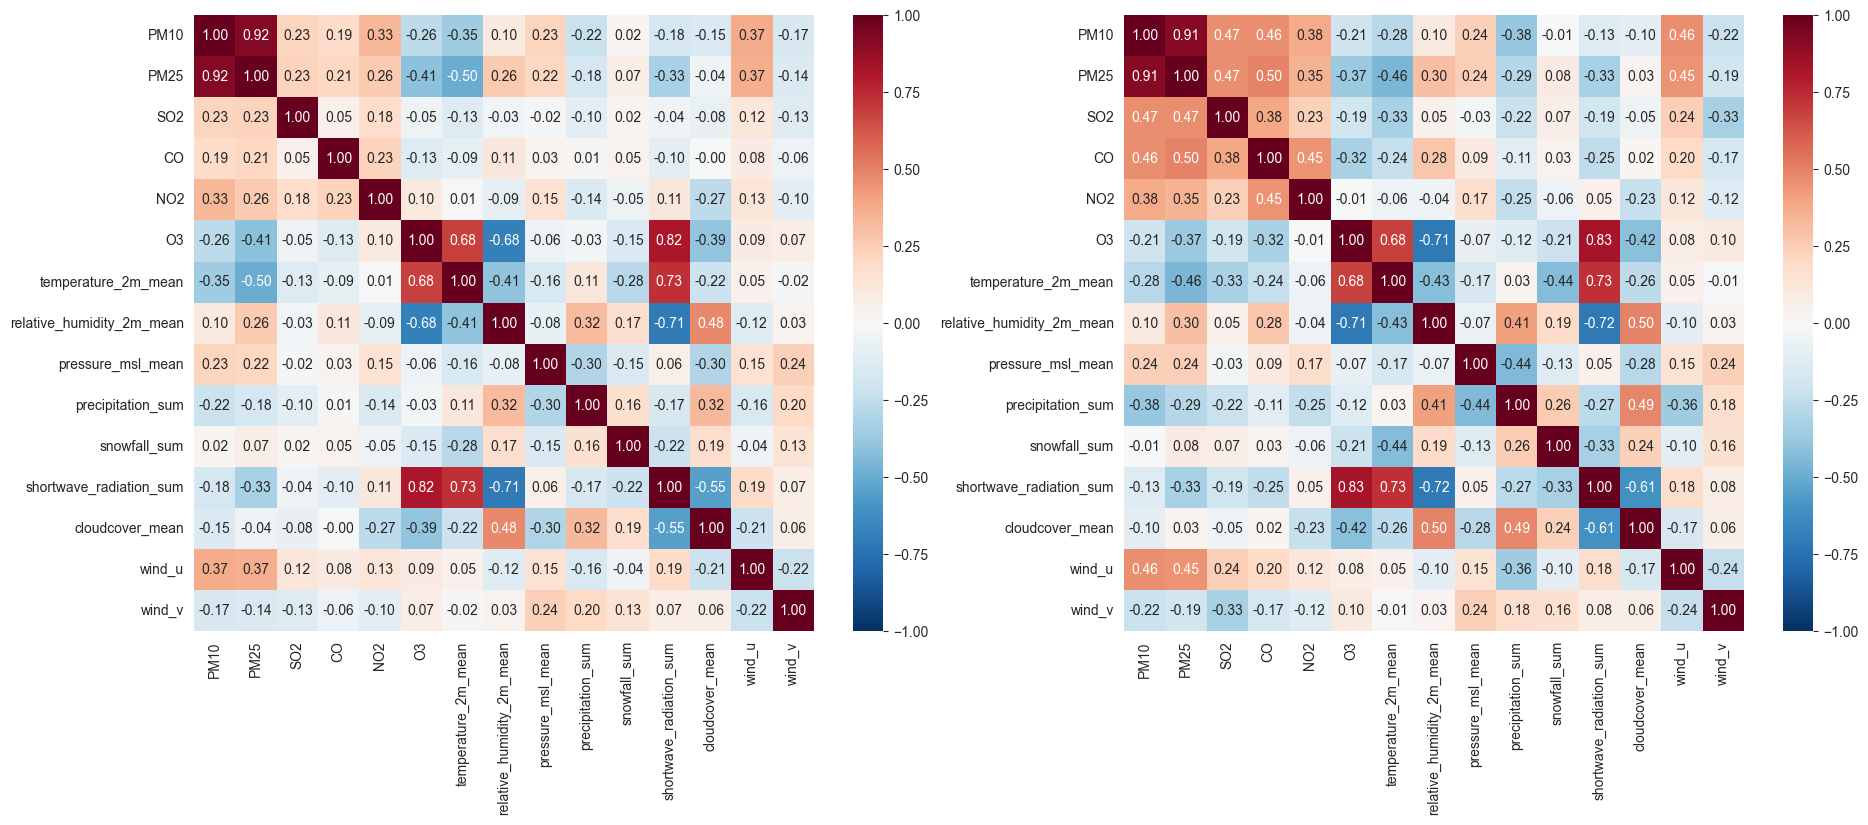

In [471]:
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.heatmap(corr_pearson, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[0], fmt='.2f')
sns.heatmap(corr_spearman, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[1], fmt='.2f')
plt.show()

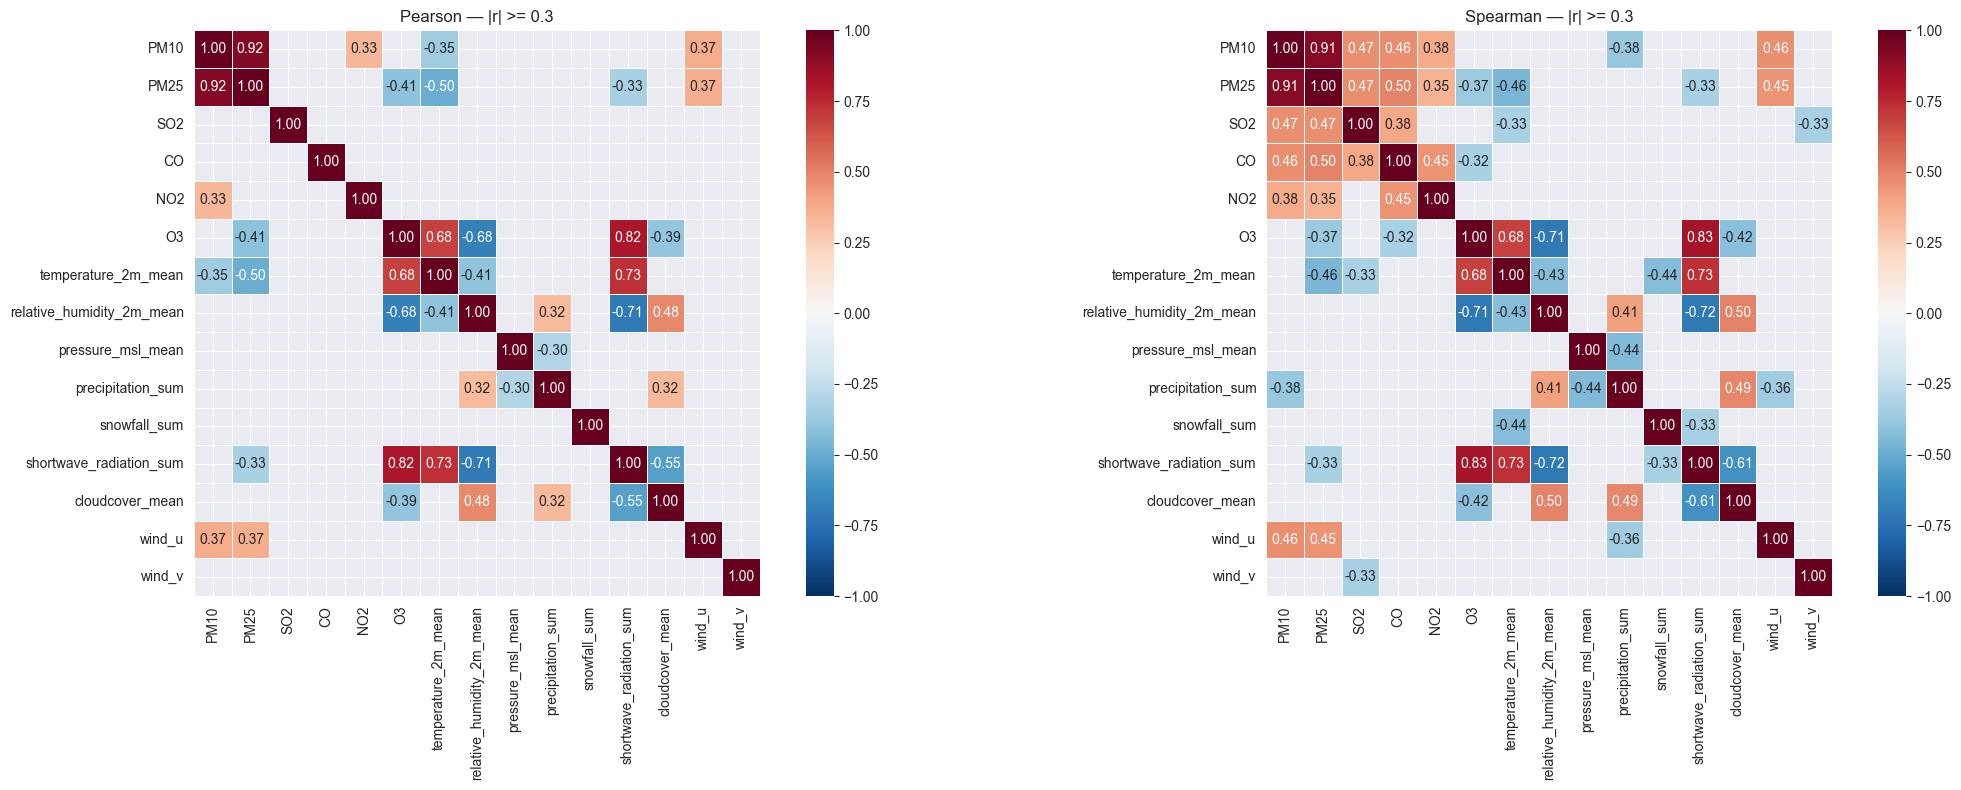

In [472]:
r_df_p = df.corr(method='pearson')
r_df_s = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(r_df_p, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_p.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Pearson — |r| >= 0.3')

sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Spearman — |r| >= 0.3') 

plt.tight_layout()
plt.show()

- |r| < 0.1 — efekt zaniedbywalny
- 0.1 <= |r| < 0.3 — efekt mały
- 0.3 <= |r| < 0.5 — efekt średni
- |r| >= 0.5 — efekt duży

Konwencja "small/medium/large effect" Cohena 

In [473]:
POLLUTANTS = ['PM10', 'PM25', 'SO2', 'CO', 'NO2', 'O3']

METEO = ["temperature_2m_mean", 
        'relative_humidity_2m_mean',
        #  'pressure_msl_mean',
         'precipitation_sum',
        #  'snowfall_sum',
         'shortwave_radiation_sum',
         'cloudcover_mean',
         'wind_u',
         'wind_v']

In [474]:
df_old = df.copy()
df = df[POLLUTANTS + METEO]
df_clean = df.copy()

In [475]:
# df['Year'] = df.index.year
df['Month'] = df.index.month_name()
# df['DayOfWeek'] = df.index.day_name()

In [476]:
heating_months = ['October', 'November', 'December', 'January', 'February','March']
df['Heating_season'] = df['Month'].isin(heating_months).map({True: 'Heating', False: 'Non-Heating'})

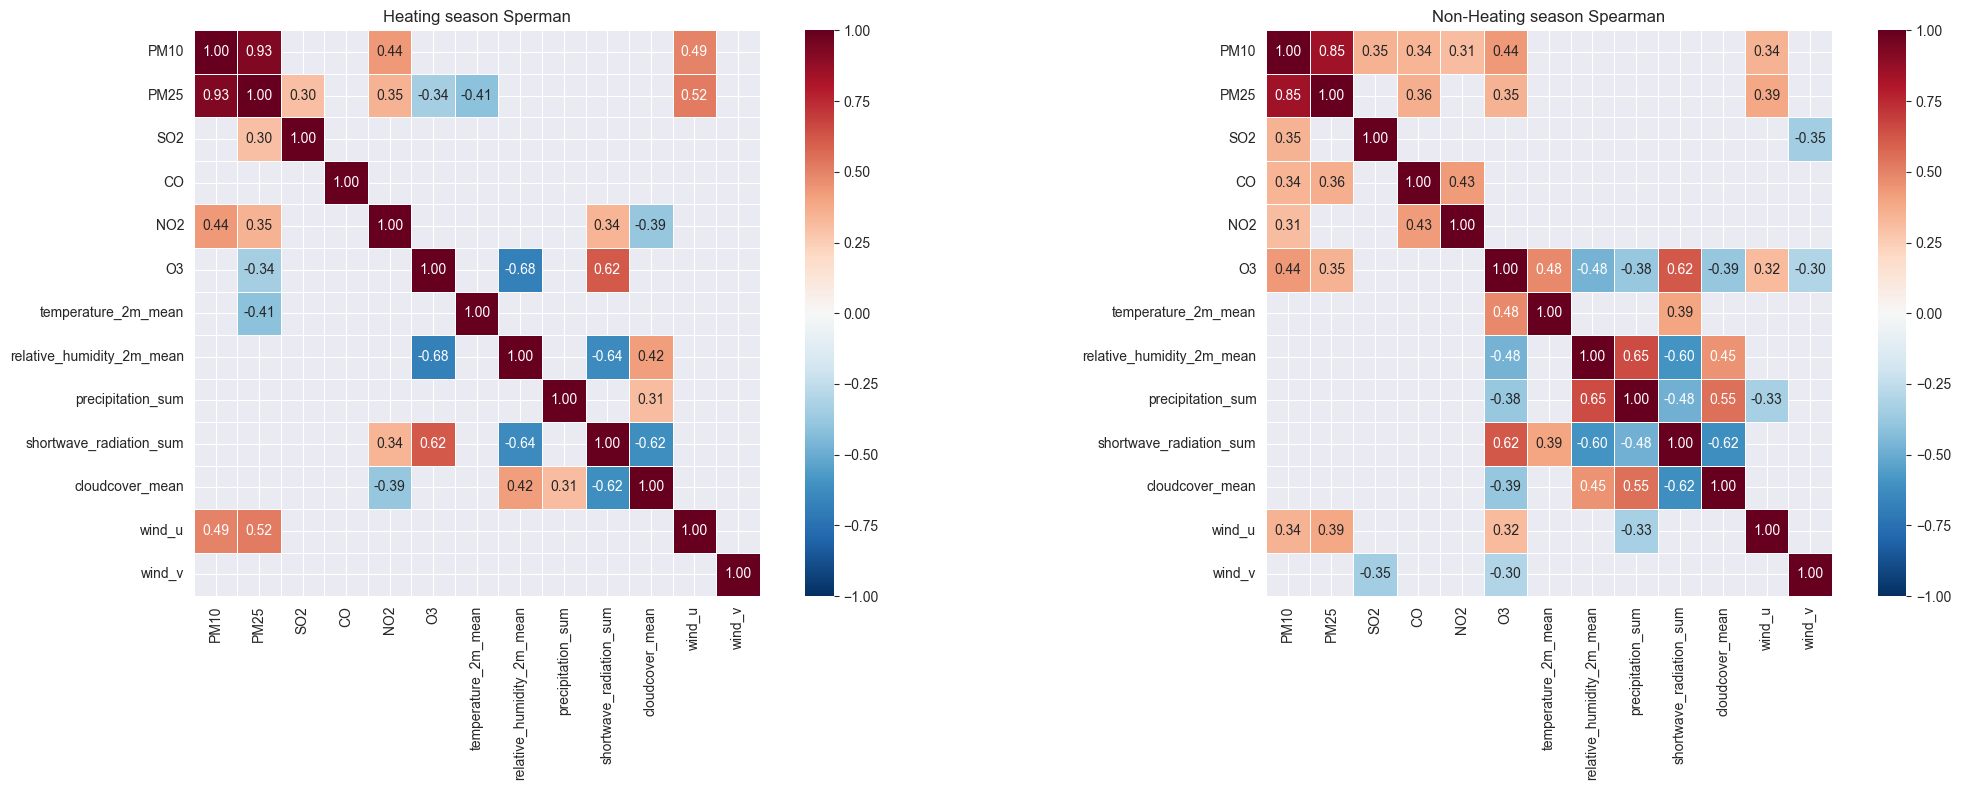

In [477]:
r_df_H = df[df['Heating_season'] == 'Heating'][POLLUTANTS + METEO].corr(method='pearson')
r_df_NH = df[df['Heating_season'] == 'Non-Heating'][POLLUTANTS + METEO].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(r_df_H, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_H.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Heating season Sperman')

sns.heatmap(r_df_NH, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_NH.abs() <= 0.3,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Non-Heating season Spearman') 

plt.tight_layout()
plt.show()

In [478]:
# season_mapping = {
#     1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
#     6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn',
#     11: 'Autumn', 12: 'Winter'
# }

# df['season'] = df.index.month.map(season_mapping)

In [479]:
# r_df_w = df[df['season'] == 'Winter'][POLLUTANTS + METEO].corr(method='spearman')
# r_df_s = df[df['season'] == 'Spring'][POLLUTANTS + METEO].corr(method='spearman')
# r_df_su = df[df['season'] == 'Summer'][POLLUTANTS + METEO].corr(method='spearman')
# r_df_a = df[df['season'] == 'Autumn'][POLLUTANTS + METEO].corr(method='spearman')

# fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# sns.heatmap(r_df_w, annot=True, fmt='.2f',
#             vmin=-1, vmax=1, cmap="RdBu_r", center=0,
#             mask=r_df_w.abs() <= 0.3,
#             square=True, linewidths=0.5,
#             ax=axes[0, 0])
# axes[0, 0].set_title('Winter Spearman')

# sns.heatmap(r_df_s, annot=True, fmt='.2f',
#             vmin=-1, vmax=1, cmap="RdBu_r", center=0,
#             mask=r_df_s.abs() <= 0.3,
#             square=True, linewidths=0.5,
#             ax=axes[0, 1])
# axes[0, 1].set_title('Spring Spearman') 

# sns.heatmap(r_df_su, annot=True, fmt='.2f',
#             vmin=-1, vmax=1, cmap="RdBu_r", center=0,
#             mask=r_df_su.abs() <= 0.3,
#             square=True, linewidths=0.5,
#             ax=axes[1, 0])
# axes[1, 0].set_title('Summer Spearman')

# sns.heatmap(r_df_a, annot=True, fmt='.2f',
#             vmin=-1, vmax=1, cmap="RdBu_r", center=0,
#             mask=r_df_a.abs() <= 0.3,
#             square=True, linewidths=0.5,
#             ax=axes[1, 1])
# axes[1, 1].set_title('Autumn Spearman') 

# plt.tight_layout()
# plt.show()

jedno, pory roku albo heating ni heating, w zaleznosci co daje wiecej info

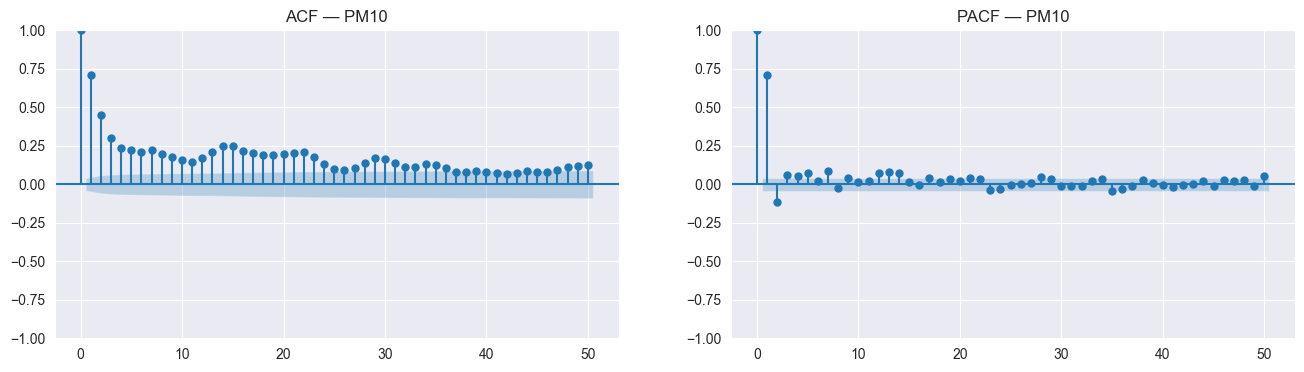

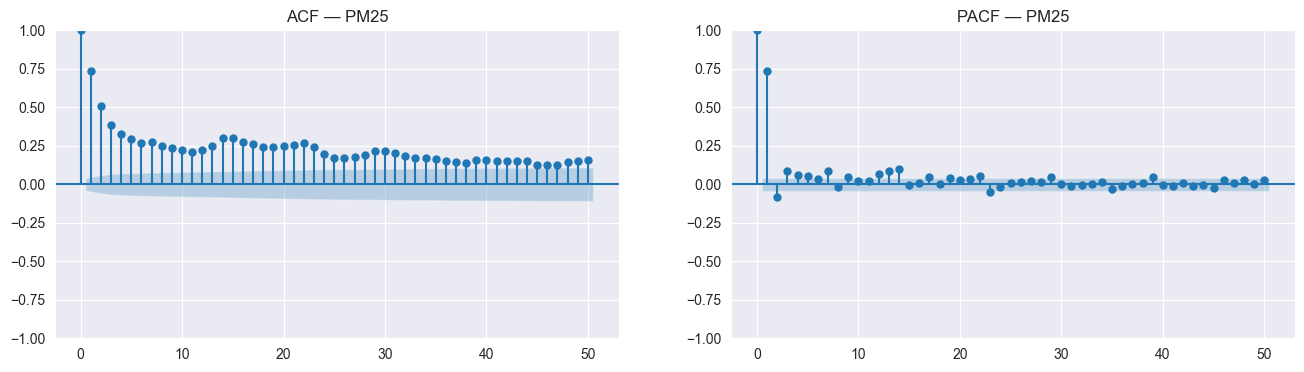

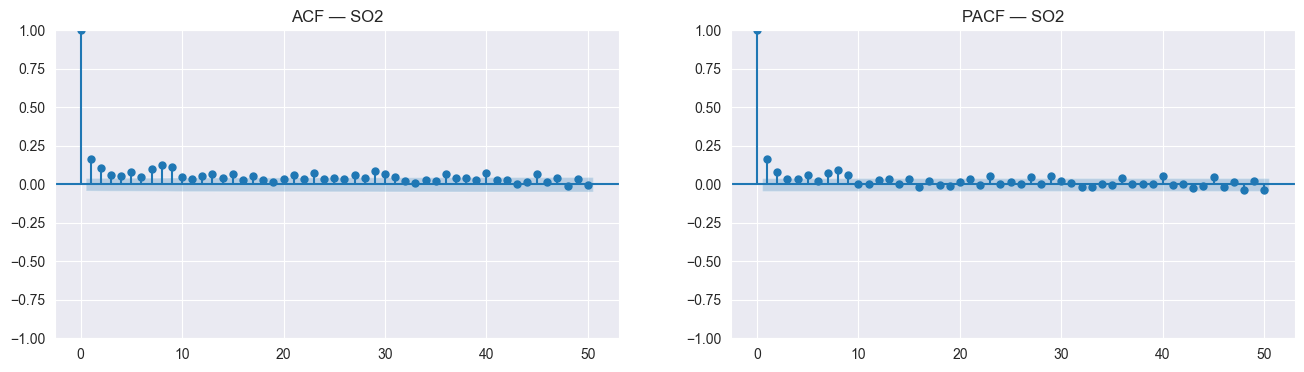

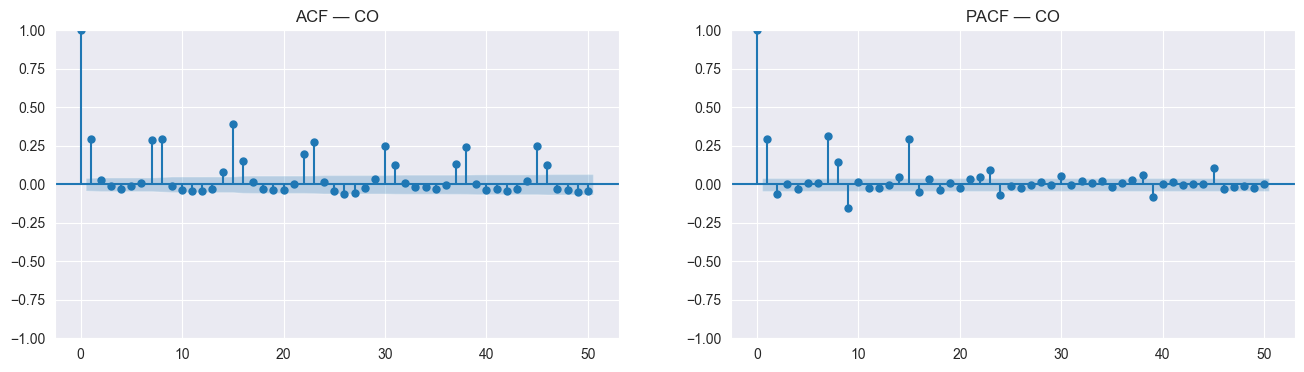

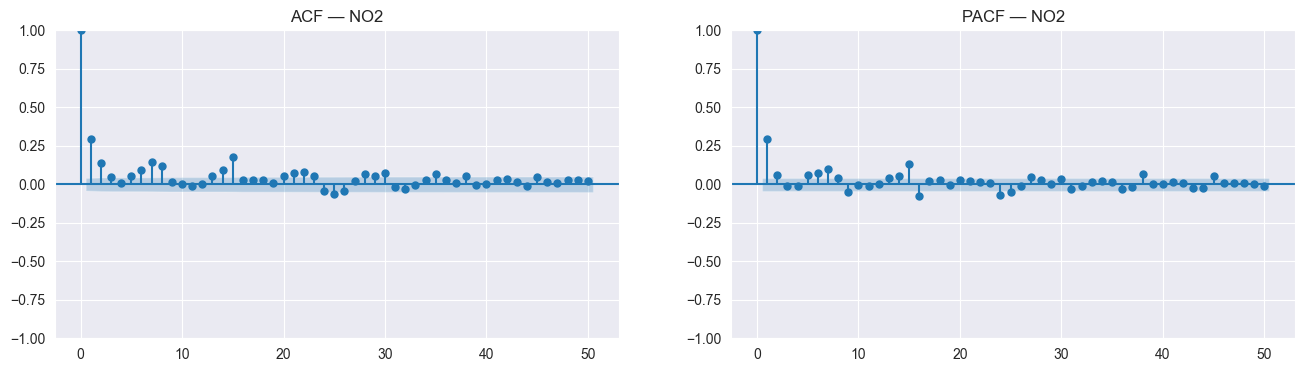

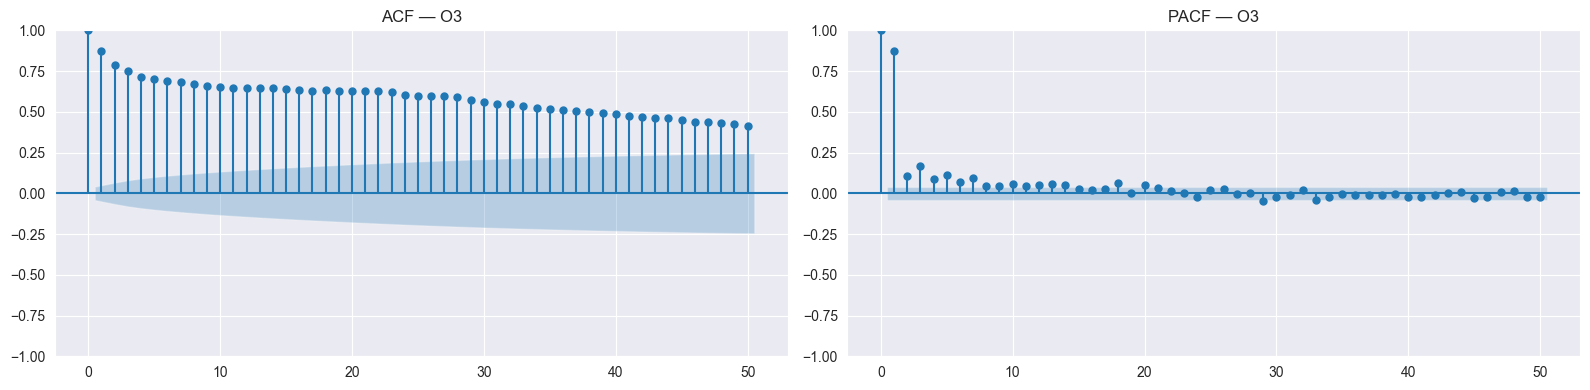

In [480]:
for i, col in enumerate(POLLUTANTS):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
    s = df[col].dropna()
    plot_acf(s, lags=50, ax=axes[0], title=f'ACF — {col}')
    plot_pacf(s, lags=50, ax=axes[1], title=f'PACF — {col}', method='ywm')
plt.tight_layout()
plt.show()

spodziewalibysmy sie okresu 24 ale widac inne, gdzies sie pojawia 24 ale to nie tylko to (moze po dodaniu temperatury itp nam sie to uwypukli)

In [645]:
# sredni schemat dobowy nie wiem jak zrobic bo mam dane dobowe dla pogody a nie pogodowe

In [669]:
df_for_modeling = df_clean.copy()
date = df_for_modeling.index
df_for_modeling = df_for_modeling.asfreq('D')

df_train = df_for_modeling.loc[:'2025-03-30']
df_test = df_for_modeling.loc['2025-03-31':]

In [670]:
df_mslt = pd.DataFrame(index=df_train.index)

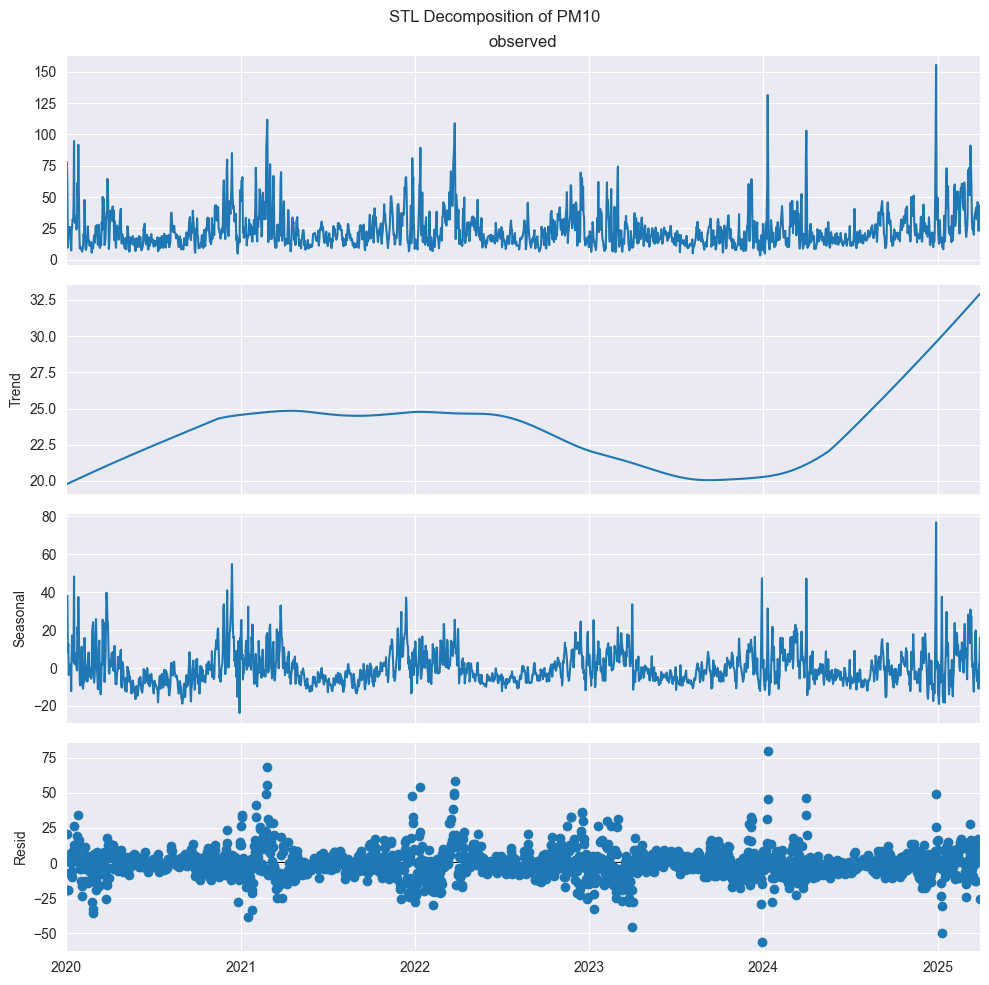

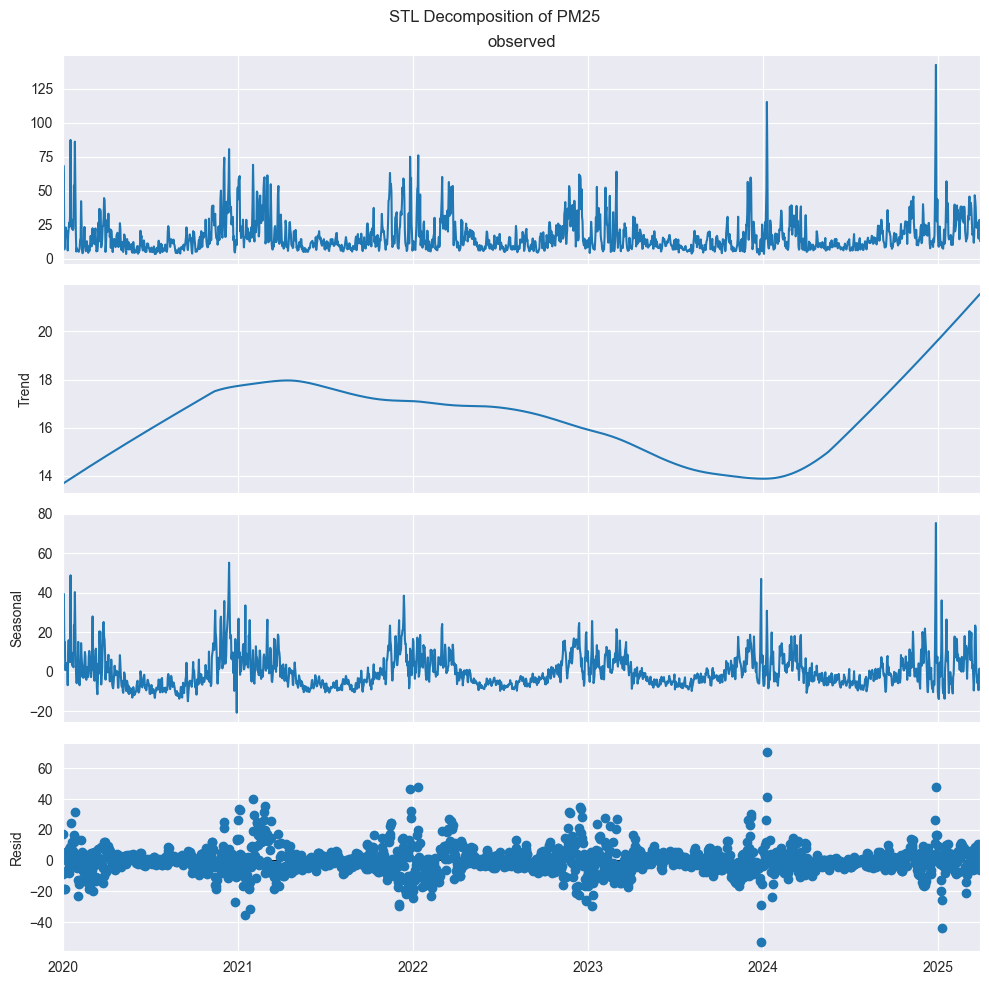

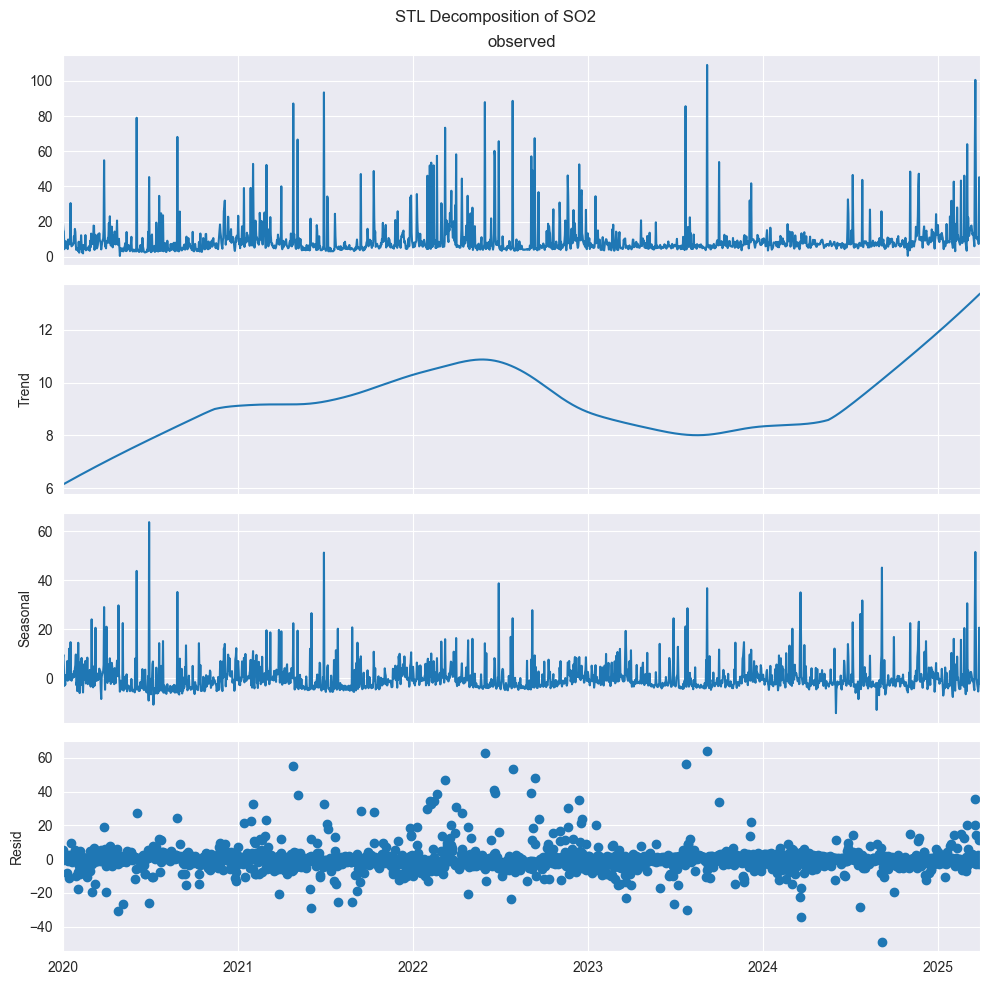

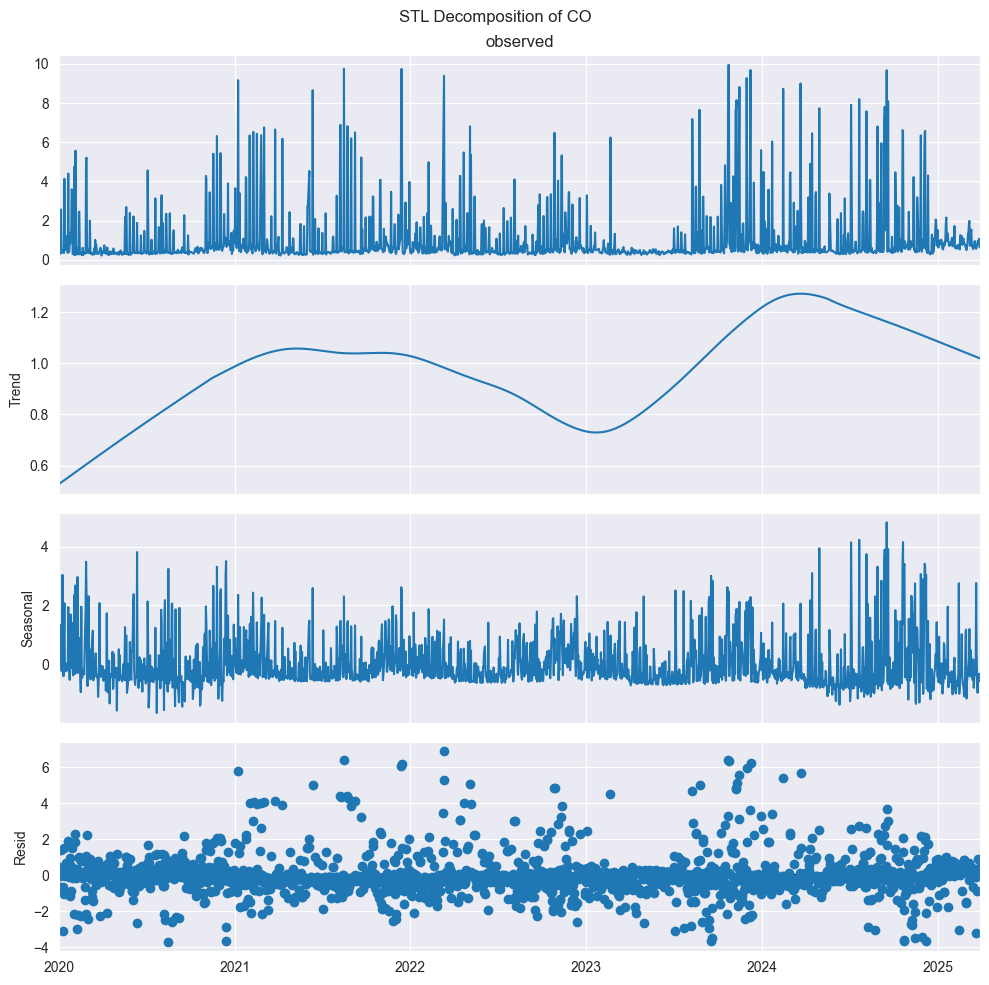

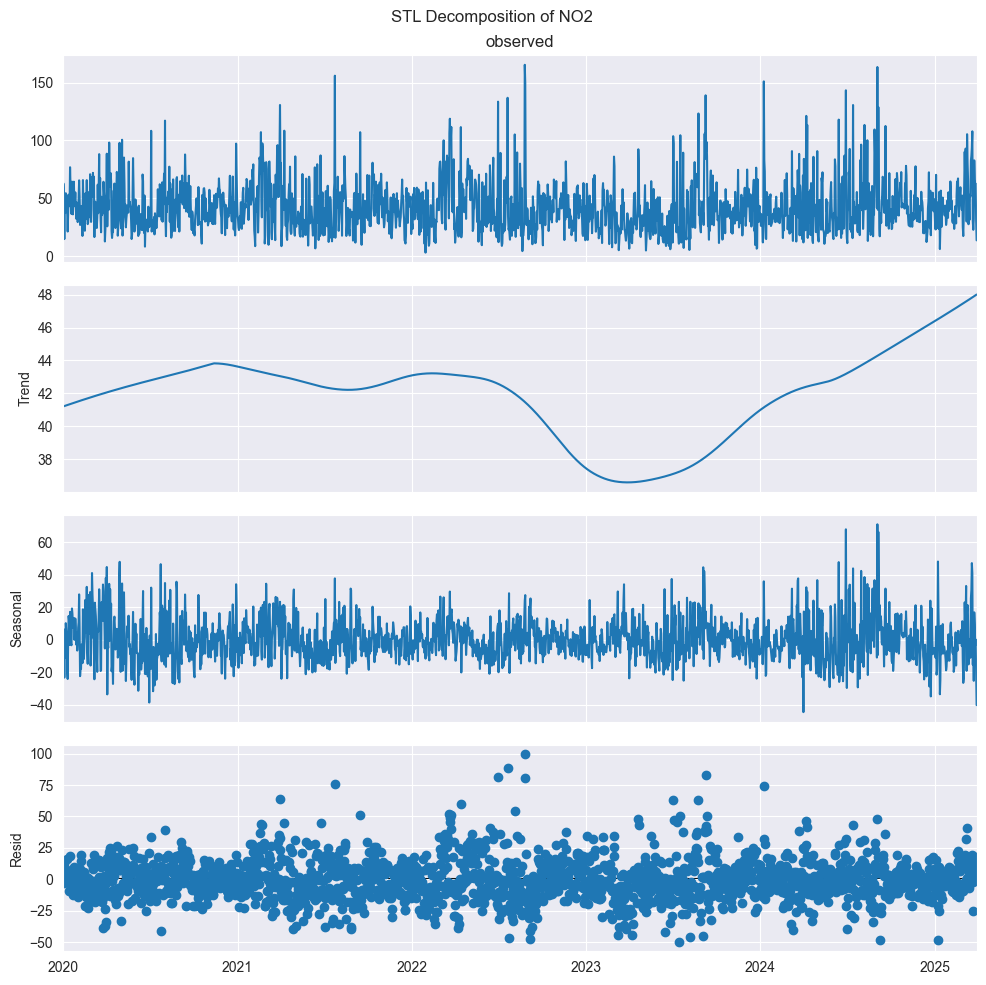

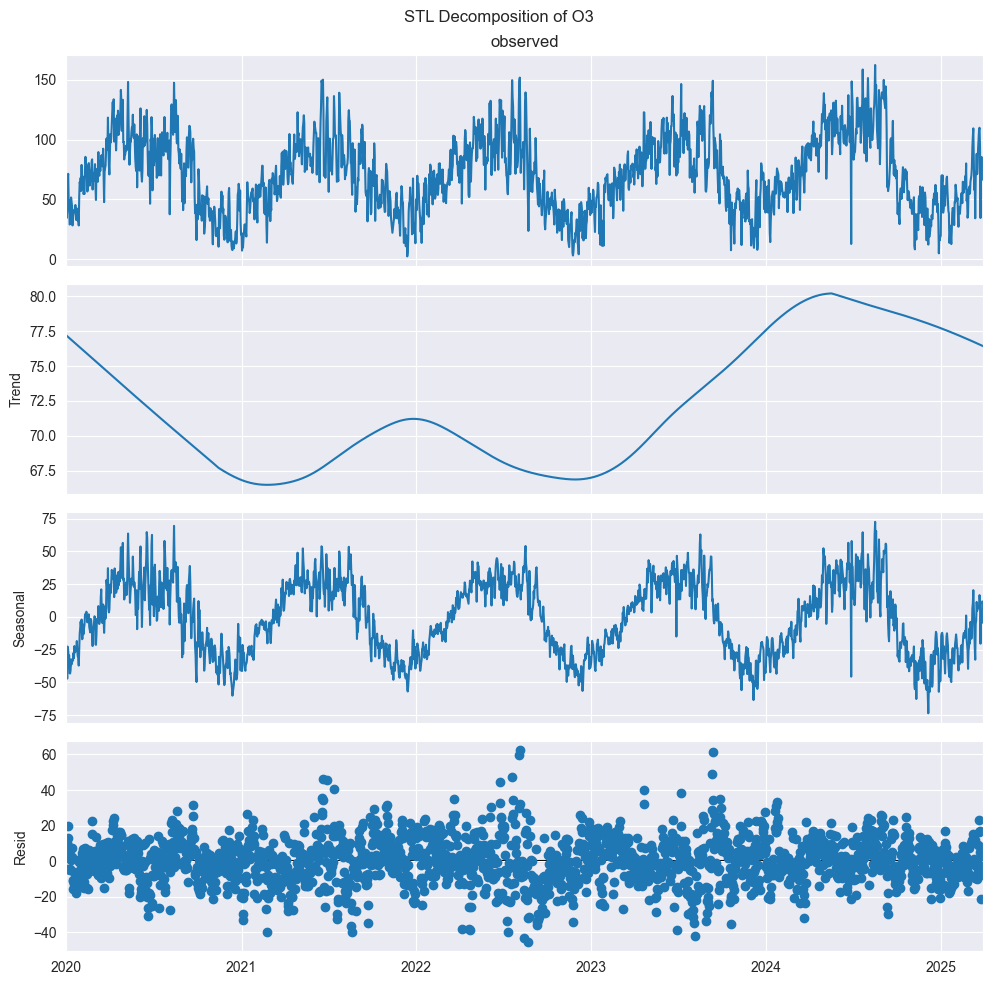

In [672]:
for col in POLLUTANTS:
    stl = MSTL(df_train[col], periods=(365))
    result = stl.fit()
    
    df_mslt[f'{col}_resid'] = result.resid
    df_mslt[f'{col}_trend'] = result.trend
    # df_mslt[f'{col}_seasonal_7'] = result.seasonal['seasonal_7']
    df_mslt[f'{col}_seasonal_365'] = result.seasonal


    fig = result.plot()
    fig.set_size_inches(10, 10)
    fig.suptitle(f'STL Decomposition of {col}')
    plt.tight_layout()
    plt.show()
    

In [649]:
for col in POLLUTANTS:
    series = df_train[col]
    mstl = MSTL(series, periods=[7, 365]).fit()
    
    # seasonal_strength = 1 - Var(resid) / Var(resid + seasonal)
    # wartość 0 = brak sezonowości, 1 = pełna sezonowość
    resid = mstl.resid
    seasonal_7 = mstl.seasonal["seasonal_7"]
    seasonal_365 = mstl.seasonal["seasonal_365"]
    
    strength_7 = max(0, 1 - np.var(resid) / np.var(resid + seasonal_7))
    strength_365 = max(0, 1 - np.var(resid) / np.var(resid + seasonal_365))
    
    print(f"{col:6s}: weekly = {strength_7:.3f}, "
          f"yearly = {strength_365:.3f}")

PM10  : weekly = 0.184, yearly = 0.461
PM25  : weekly = 0.176, yearly = 0.520
SO2   : weekly = 0.233, yearly = 0.415
CO    : weekly = 0.329, yearly = 0.396
NO2   : weekly = 0.260, yearly = 0.382
O3    : weekly = 0.158, yearly = 0.828


In [650]:
dummies_train = pd.get_dummies(df_train.index.month, prefix='month').astype(int)
dummies_train.index = df_train.index

dummies_test = pd.get_dummies(df_test.index.month, prefix='month').astype(int)
dummies_test.index = df_test.index

In [ ]:
# for col in POLLUTANTS:
#     df_train.loc[:, f'{col}_minus_mean'] = df_train.loc[:, col] - df_train.loc[:, col].mean()
#     df_train.loc[:, f'{col}_mean'] = df_train.loc[:, col].mean()

In [651]:
def SARIMAX_grid_search(df_train, target, exog, p_values, d_values, q_values, verbose=False): # ewentualnie mam odnąć zwykłą średnią (linie prosta)
    y_train = df_train[target]
    
    best_aic = np.inf
    best_order = None
    
    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            model = SARIMAX(
                y_train,
                exog=exog,
                order=(p, d, q),
                seasonal_order=(0, 0, 0, 0),
                trend='n',
                # missing='drop',
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)
            if verbose:
                print(f"  ({p},{d},{q}): AIC={fit.aic:.2f}")
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
        except Exception:
            continue
    
    print(f"{target}: Best SARIMA order={best_order}, AIC={best_aic:.2f}")
    
    sarima = SARIMAX(
        y_train,
        exog=exog,
        order=best_order,
        seasonal_order=(0, 0, 0, 0),
        trend='n',
        # missing='drop',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima.fit(disp=False)
    print(sarima_fit.summary())
    print('\n')
    
    return sarima_fit, best_order, best_aic

In [652]:
assert df_train.index.equals(dummies_train.index)

fitted_models = {}
orders = {}
aics = {}

for col in POLLUTANTS:
    print(f"\n{'='*60}")
    print(f"Polutant: {col}")
    
    fit, order, aic = SARIMAX_grid_search(
        df_train, col, dummies_train,
        p_values=[0, 1, 2, 3],
        d_values=[0],
        q_values=[0, 1, 2, 3]
    )
    
    fitted_models[col] = fit
    orders[col] = order
    aics[col] = aic


for col in POLLUTANTS:
    print(f"{col}: order={orders[col]}, AIC={aics[col]:.2f}")


Polutant: PM10


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



PM10: Best SARIMA order=(1, 0, 3), AIC=14284.37
                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -7125.183
Date:                Mon, 18 May 2026   AIC                          14284.366
Time:                        23:03:39   BIC                          14378.816
Sample:                    01-01-2020   HQIC                         14319.125
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       26.4105      1.402     18.832      0.000      23.662      29.159
month_2       27.1235      1.479     18.340      0.000      24.225      30.022
mont

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



PM25: Best SARIMA order=(1, 0, 3), AIC=13506.22
                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -6736.111
Date:                Mon, 18 May 2026   AIC                          13506.222
Time:                        23:04:13   BIC                          13600.672
Sample:                    01-01-2020   HQIC                         13540.981
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       20.5847      1.120     18.383      0.000      18.390      22.779
month_2       20.3457      1.229     16.550      0.000      17.936      22.755
mont

...

                               SARIMAX Results                                
Dep. Variable:                     CO   No. Observations:                 1916
Model:               SARIMAX(2, 0, 3)   Log Likelihood               -3249.231
Date:                Mon, 18 May 2026   AIC                           6534.462
Time:                        23:05:41   BIC                           6634.468
Sample:                    01-01-2020   HQIC                          6571.266
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1        0.9763      0.143      6.829      0.000       0.696       1.256
month_2        1.0791      0.125      8.613      0.000       0.834       1.325
month_3        0.9041      0.140      6.439      0.0

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



NO2: Best SARIMA order=(1, 0, 3), AIC=16950.01
                               SARIMAX Results                                
Dep. Variable:                    NO2   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -8458.005
Date:                Mon, 18 May 2026   AIC                          16950.010
Time:                        23:06:16   BIC                          17044.460
Sample:                    01-01-2020   HQIC                         16984.769
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       40.7238      3.418     11.916      0.000      34.025      47.422
month_2       42.2007      3.257     12.958      0.000      35.818      48.584
month

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



O3: Best SARIMA order=(3, 0, 3), AIC=15631.78
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                 1916
Model:               SARIMAX(3, 0, 3)   Log Likelihood               -7796.888
Date:                Mon, 18 May 2026   AIC                          15631.776
Time:                        23:07:11   BIC                          15737.338
Sample:                    01-01-2020   HQIC                         15670.625
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_1       45.7519      4.166     10.982      0.000      37.586      53.918
month_2       59.4042      4.392     13.525      0.000      50.796      68.013
month_

In [ ]:
def plot_full_predictions(fit, df_train, df_test, target, 
                          dummies_train, dummies_test,
                          alpha_ci=0.5, burnin=30):
    y_train = df_train[target]
    y_test = df_test[target]
#     mean = df_train[f'{target}_mean']

    # Train: in-sample 1-step
    pred_train = fit.get_prediction(start=0, end=len(y_train) - 1)
    pred_train_mean = pred_train.predicted_mean 
    pred_train_ci = pred_train.conf_int(alpha=alpha_ci)
    
    # Test: walk-forward 1-step
    fit_on_test = fit.apply(endog=y_test, exog=dummies_test)
    pred_test = fit_on_test.get_prediction(start=0, end=len(y_test) - 1)
    pred_test_mean = pred_test.predicted_mean 
    pred_test_ci = pred_test.conf_int(alpha=alpha_ci)
    
    n_train = len(y_train)
    idx_train = np.arange(n_train)
    idx_test = np.arange(n_train, n_train + len(y_test))
    full_obs = np.concatenate([y_train.values, y_test.values])
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.xaxis.grid()
    
    ax.plot(np.arange(len(full_obs)), full_obs, 'k.', alpha=0.6, label='Real data')
    
    ax.plot(idx_train, pred_train_mean.values, color='C0', 
            label='In-sample 1-step (train)')#, linestyle=':')
    ax.fill_between(idx_train[burnin:], 
                    pred_train_ci.iloc[burnin:, 0], pred_train_ci.iloc[burnin:, 1], 
                    color='C0', alpha=0.6)
    
    ax.plot(idx_test, pred_test_mean.values, c='C2', #linestyle=':',
            label='Walk-forward 1-step (test)')
    ax.fill_between(idx_test,
                    pred_test_ci.iloc[:, 0], pred_test_ci.iloc[:, 1],
                    color='C2', alpha=0.6)
    
    ax.axvline(n_train - 0.5, color='C3', linewidth=2)
    
    y_min = full_obs.min()
    y_max = full_obs.max()
    margin = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - margin, y_max + margin)
    
    ax.set(title=f'{target} — in-sample (train) + walk-forward (test)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

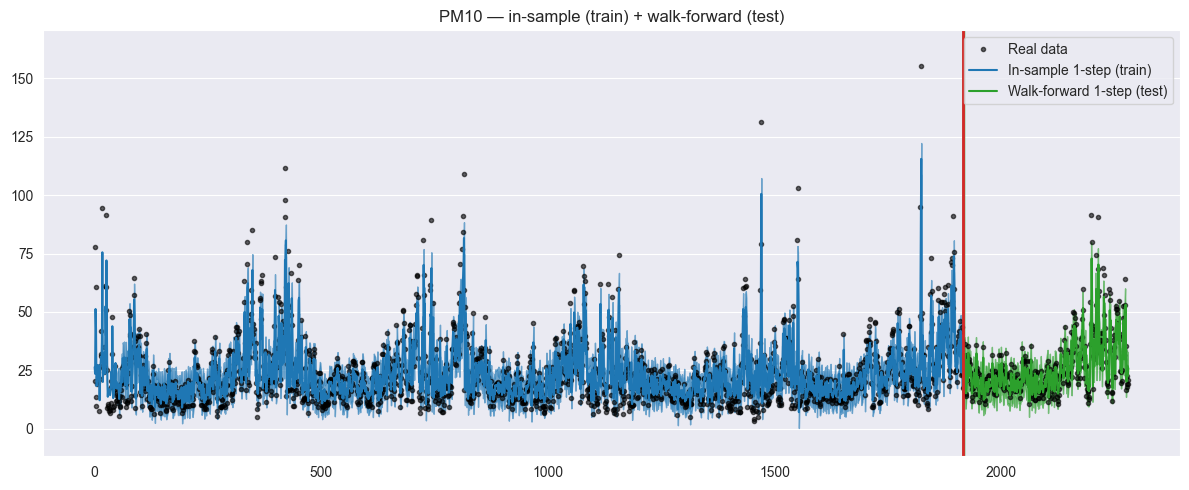

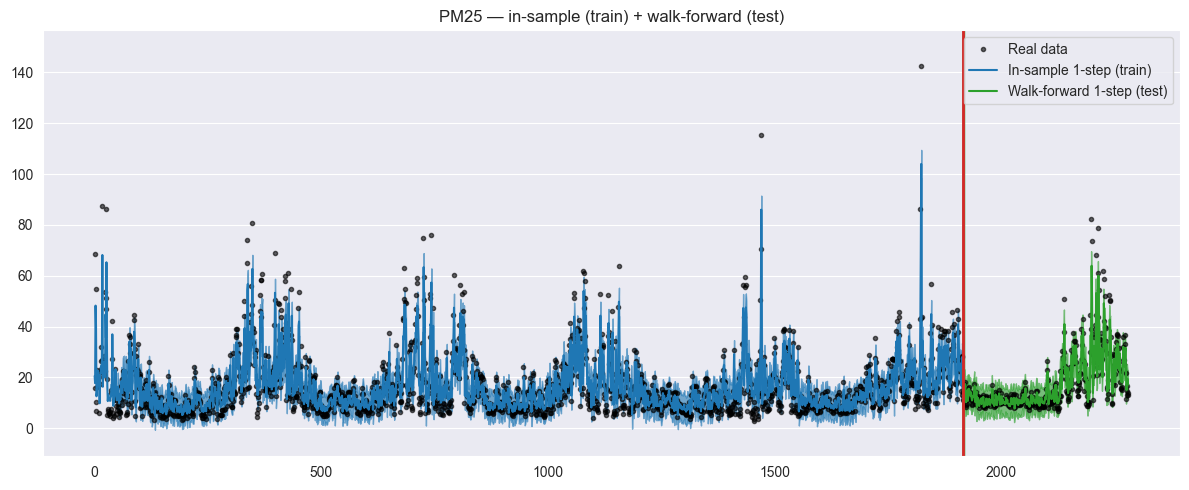

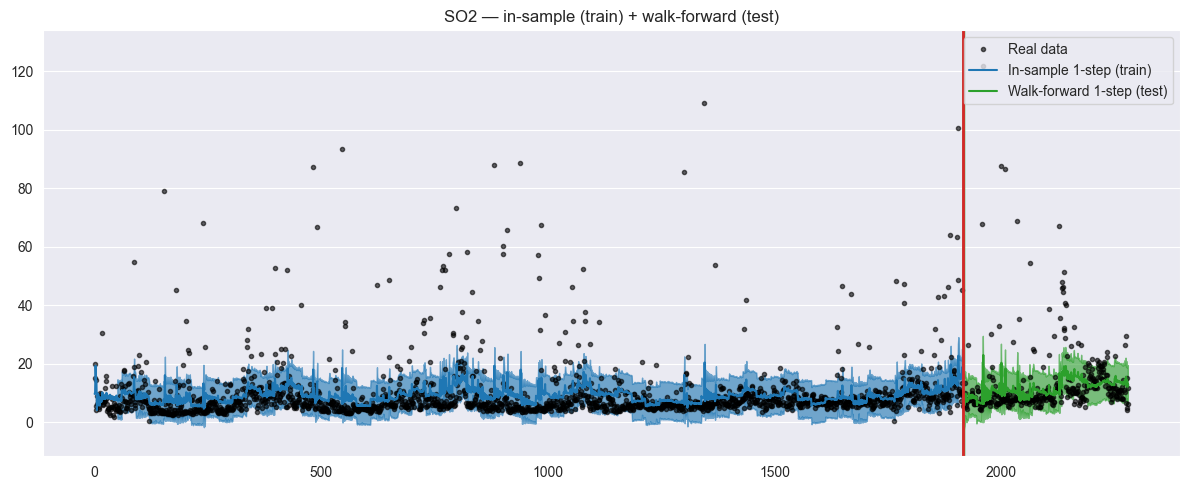

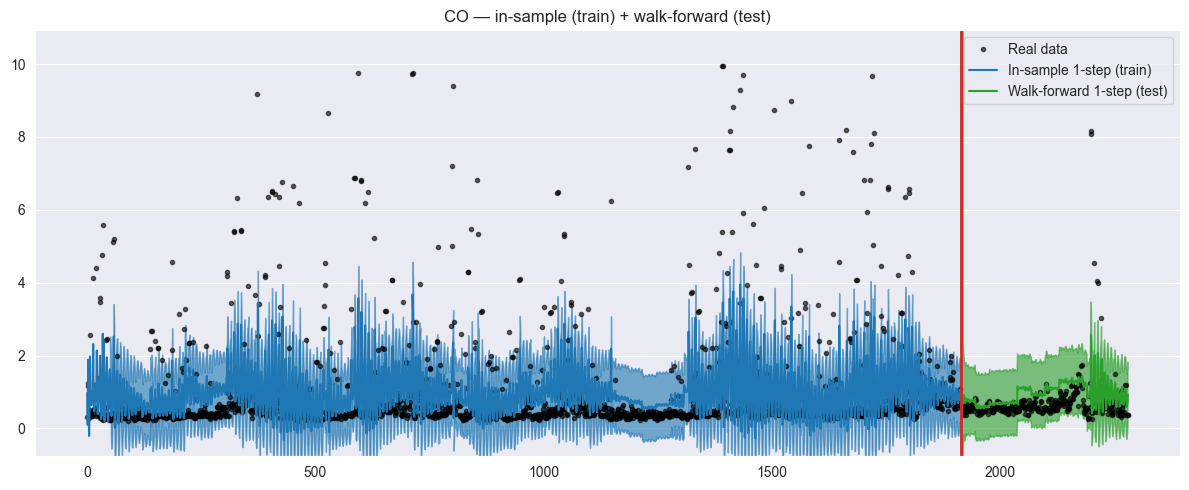

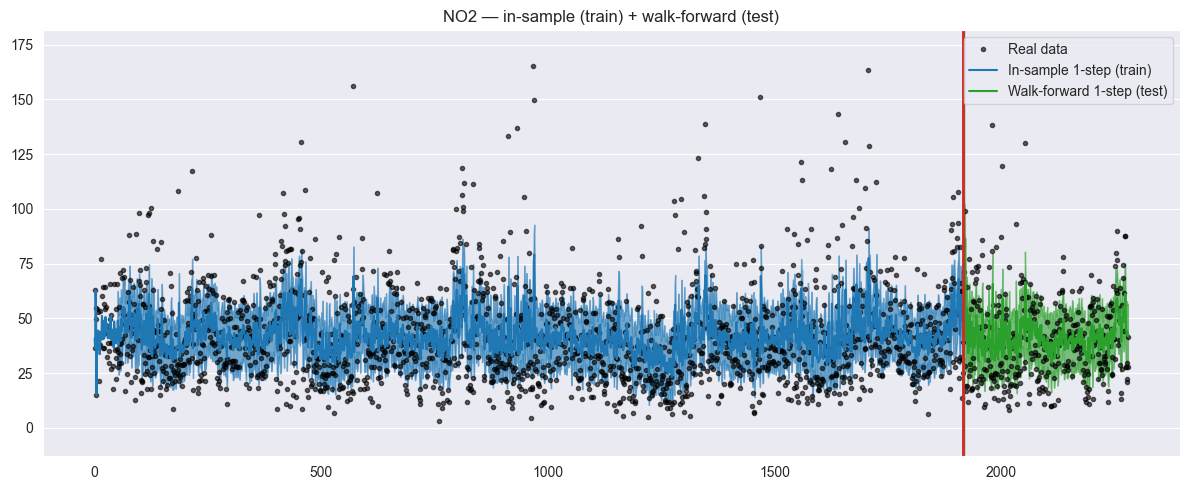

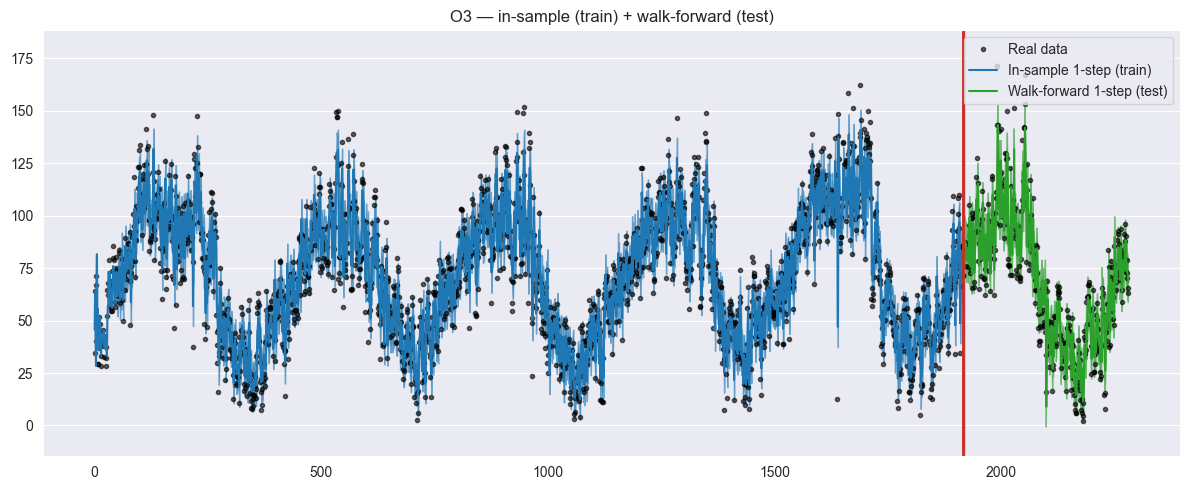

In [654]:
for col in POLLUTANTS:
    plot_full_predictions(
        fit=fitted_models[col],
        df_train=df_train,
        df_test=df_test,
        target=col,
        dummies_train=dummies_train,
        dummies_test=dummies_test
    )

In [655]:
def evaluate_on_test(fit, df_test, target, exog_test):
    y_test = df_test[target]
    
    fit_on_test = fit.apply(endog=y_test, exog=exog_test)
    pred = fit_on_test.fittedvalues
    
    rmse = np.sqrt(((y_test - pred)**2).mean())
    mae = (y_test - pred).abs().mean()
    r2 = 1 - ((y_test - pred)**2).sum() / ((y_test - y_test.mean())**2).sum()
    mape = ((y_test - pred) / y_test.replace(0, np.nan)).abs().mean() * 100
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}


results = []
for col in POLLUTANTS:
    metrics = evaluate_on_test(fitted_models[col], df_test, col, dummies_test)
    results.append({
        'polutant': col,
        'order': orders[col],
        'aic': aics[col],
        **metrics
    })

results_df = pd.DataFrame(results)
results_df.round(2)

,polutant,order,aic,rmse,mae,r2,mape
0,PM10,"(1, 0, 3)",14284.37,8.37,5.65,0.58,21.33
1,PM25,"(1, 0, 3)",13506.22,6.96,4.09,0.68,21.57
2,SO2,"(2, 0, 3)",14041.55,12.30,5.79,-0.01,40.25
3,CO,"(2, 0, 3)",6534.46,0.67,0.38,0.04,58.62
4,NO2,"(1, 0, 3)",16950.01,19.67,15.06,0.02,52.40
5,O3,"(3, 0, 3)",15631.78,14.53,11.34,0.79,26.09


In [ ]:
# # Dla ARIMAX: 11 dummies + intercept
# dummies_11 = pd.get_dummies(df.index.month, prefix='month', drop_first=True).astype(int)
# dummies_11.index = df.index
# dummies_11_train = dummies_11.loc[:TRAIN_END]
# dummies_11_test = dummies_11.loc['2025-01-01':]


# def fit_arimax_dummies(df_train, target, dummies_train, p_values, q_values):
#     """Podejście 2: ARIMAX z 11 dummies + intercept."""
#     y_train = df_train[target]
    
#     best_aic = np.inf
#     best_order = None
    
#     for p, q in itertools.product(p_values, q_values):
#         try:
#             model = SARIMAX(
#                 y_train,
#                 exog=dummies_train,             # 11 dummies
#                 order=(p, 0, q),
#                 seasonal_order=(0, 0, 0, 0),
#                 trend='c',                       # ← intercept jawny
#                 missing='drop',
#                 enforce_stationarity=False,
#                 enforce_invertibility=False
#             )
#             fit = model.fit(disp=False)
#             if fit.aic < best_aic:
#                 best_aic = fit.aic
#                 best_order = (p, 0, q)
#         except Exception:
#             continue
    
#     print(f"{target}: ARIMAX dummies (11+const), order={best_order}, AIC={best_aic:.2f}")
    
#     final = SARIMAX(
#         y_train, exog=dummies_train, order=best_order,
#         trend='c', missing='drop',
#         enforce_stationarity=False, enforce_invertibility=False
#     ).fit(disp=False)
    
#     return final, best_order, best_aic

# Dorzucenie zmiennych METEO

In [663]:
scaler = StandardScaler()
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

df_train_scaled[METEO] = scaler.fit_transform(df_train[METEO])
df_test_scaled[METEO] = scaler.transform(df_test[METEO])

# Sanity check
assert abs(df_train_scaled[METEO].mean()).max() < 0.01, "Train mean not0!"
assert abs(df_train_scaled[METEO].std() - 1).max() < 0.01, "Train std not 1!"
print("Standaryzacja OK")

Standaryzacja OK


In [664]:
exog_train = pd.concat([dummies_train, df_train_scaled[METEO]], axis=1) 
exog_test = pd.concat([dummies_test, df_test_scaled[METEO]], axis=1)

In [659]:
assert df_train.index.equals(exog_train.index)

fitted_models_X = {}
orders_X = {}
aics_X = {}

for col in POLLUTANTS:
    print(f"\n{'='*60}")
    print(f"Polutant: {col}")
    
    fit, order, aic = SARIMAX_grid_search(
        df_train, col, exog_train,
        p_values=[0, 1, 2, 3],
        d_values=[0],
        q_values=[0, 1, 2, 3]
    )
    
    fitted_models_X[col] = fit
    orders_X[col] = order
    aics_X[col] = aic


for col in POLLUTANTS:
    print(f"{col}: order={orders_X[col]}, AIC={aics_X[col]:.2f}")


Polutant: PM10


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppDa

PM10: Best SARIMA order=(1, 0, 3), AIC=14076.14


c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -7014.071
Date:                Mon, 18 May 2026   AIC                          14076.142
Time:                        23:17:49   BIC                          14209.483
Sample:                    01-01-2020   HQIC                         14125.213
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
month_1                      25.6148      1.760     14.554      0.000      22.165      29.064
month_2                      27.2405      1.561     17.446      0.000      24.180     

...

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                               SARIMAX Results                                
Dep. Variable:                    NO2   No. Observations:                 1916
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -8400.502
Date:                Mon, 18 May 2026   AIC                          16849.005
Time:                        23:23:20   BIC                          16982.346
Sample:                    01-01-2020   HQIC                         16898.076
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
month_1                      47.2913      3.911     12.091      0.000      39.626      54.957
month_2                      47.2149      3.422     13.797      0.000      40.508     

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\aleks\AppDa

O3: Best SARIMA order=(2, 0, 3), AIC=14946.35
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                 1916
Model:               SARIMAX(2, 0, 3)   Log Likelihood               -7448.174
Date:                Mon, 18 May 2026   AIC                          14946.348
Time:                        23:24:45   BIC                          15085.246
Sample:                    01-01-2020   HQIC                         14997.464
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
month_1                      78.1725      3.353     23.313      0.000      71.600      84.745
month_2                      82.2217    

c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [665]:
for col in POLLUTANTS:
    plot_full_predictions(
        fit=fitted_models[col],
        df_train=df_train_scaled,
        df_test=df_test,
        target=col,
        dummies_train=exog_train,
        dummies_test=exog_test
    )

IndexError: index 23 is out of bounds for axis 0 with size 17

In [667]:
results_X = []
for col in POLLUTANTS:
    metrics_X = evaluate_on_test(fitted_models_X[col], df_test, col, exog_test)
    results_X.append({
        'polutant': col,
        'order': orders_X[col],
        'aic': aics_X[col],
        **metrics_X
    })

results_df_X = pd.DataFrame(results_X)
results_df_X.round(2)

,polutant,order,aic,rmse,mae,r2,mape
0,PM10,"(1, 0, 3)",14076.14,8.41,5.87,0.57,22.72
1,PM25,"(1, 0, 3)",13209.07,6.72,4.38,0.70,25.89
2,SO2,"(3, 0, 3)",13981.00,12.30,5.84,-0.01,40.95
3,CO,"(2, 0, 3)",6521.67,0.68,0.41,0.02,61.51
4,NO2,"(1, 0, 3)",16849.00,18.80,14.38,0.11,48.96
5,O3,"(2, 0, 3)",14946.35,12.53,9.82,0.85,22.88


In [668]:
comparison = pd.merge(
    results_df[['polutant', 'rmse', 'mae', 'r2']].rename(
        columns={'rmse':'rmse_SARIMA', 'mae':'mae_SARIMA', 'r2':'r2_SARIMA'}
    ),
    results_df_X[['polutant', 'rmse', 'mae', 'r2']].rename(
        columns={'rmse':'rmse_SARIMAX', 'mae':'mae_SARIMAX', 'r2':'r2_SARIMAX'}
    ),
    on='polutant'
)

# Procentowa poprawa RMSE
comparison['rmse_improvement_%'] = (
    100 * (comparison['rmse_SARIMA'] - comparison['rmse_SARIMAX']) / comparison['rmse_SARIMA']
)

comparison.round(2)

,polutant,rmse_SARIMA,mae_SARIMA,r2_SARIMA,rmse_SARIMAX,mae_SARIMAX,r2_SARIMAX,rmse_improvement_%
0,PM10,8.37,5.65,0.58,8.41,5.87,0.57,-0.49
1,PM25,6.96,4.09,0.68,6.72,4.38,0.70,3.36
2,SO2,12.30,5.79,-0.01,12.30,5.84,-0.01,0.04
3,CO,0.67,0.38,0.04,0.68,0.41,0.02,-0.89
4,NO2,19.67,15.06,0.02,18.80,14.38,0.11,4.45
5,O3,14.53,11.34,0.79,12.53,9.82,0.85,13.74
